# Enterprise Data Warehouse & Sales Analytics with Snowflake

## Project Overview

This project demonstrates an end-to-end analytics workflow using a cloud-based data warehouse and Python. Data is extracted from a Snowflake data warehouse, analyzed using Pandas, visualized with Matplotlib, and used to build a simple forecasting model.

## Business Objectives

The objectives of this project are to:

- Connect Python to Snowflake.
- Query enterprise dimensional and fact tables.
- Perform exploratory data analysis (EDA).
- Identify customer and product sales trends.
- Forecast future monthly sales.
- Demonstrate business insights for executive decision-making.

---

### Technologies Used

- Snowflake
- SQL
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Jupyter Notebook
- 

# 1. Install Required Packages

The following libraries are required to connect Python with Snowflake and perform data analysis.

In [2]:
pip install snowflake-connector-python


  Using cached cryptography-49.0.0-cp311-abi3-win_amd64.whl.metadata (4.3 kB)
Using cached cryptography-49.0.0-cp311-abi3-win_amd64.whl (3.8 MB)
  Attempting uninstall: cryptography
    Found existing installation: cryptography 45.0.7
    Uninstalling cryptography-45.0.7:
      Successfully uninstalled cryptography-45.0.7
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder 6.0.7 requires ipython!=8.17.1,<9.0.0,>=8.13.0; python_version > "3.8", but you have ipython 9.5.0 which is incompatible.


In [3]:
pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.


# 2. Connect to the Snowflake Data Warehouse

In this section we establish a secure connection to Snowflake using the Snowflake Python Connector.

The connection allows us to retrieve enterprise data directly from the warehouse for analysis.

In [1]:
import snowflake.connector
import pandas as pd

conn = snowflake.connector.connect(
    user="mensahs2",
    password="6Bs.nPKeRgbsQPT",
    account="QKJOKPZ-VM64692",
    warehouse="COMPUTE_WH",
    database="DW_PROJECT",
    schema="GOLD"
)


# 3. Load Enterprise Data

Three core tables are imported:

- **DIM_CUSTOMER** – Customer information
- **DIM_PRODUCT** – Product information
- **FACT_SALES** – Sales transactions

These tables form the basis of our sales analytics workflow.

In [3]:
import pandas as pd

In [4]:
customer_df = pd.read_sql("""
SELECT *
FROM DIM_CUSTOMER
""", conn)

customer_df.head()

C:\Users\mensahs2\AppData\Local\Temp\ipykernel_21428\1632144455.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customer_df = pd.read_sql("""


,CUSTOMER_ID,CUSTOMER_KEY,FIRST_NAME,LAST_NAME,MARITAL_STATUS,GENDER,BIRTH_DATE,CREATED_DATE
0,11000.0,AW00011000,Jon,Yang,Married,Male,None,2025-10-06
1,11001.0,AW00011001,Eugene,Huang,Single,Male,None,2025-10-06
2,11002.0,AW00011002,Ruben,Torres,Married,Male,None,2025-10-06
3,11003.0,AW00011003,Christy,Zhu,Single,Female,None,2025-10-06
4,11004.0,AW00011004,Elizabeth,Johnson,Single,Female,None,2025-10-06


In [5]:
product_df = pd.read_sql("""
SELECT *
FROM DIM_PRODUCT
""", conn)

product_df.head()

C:\Users\mensahs2\AppData\Local\Temp\ipykernel_21428\4042862529.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_df = pd.read_sql("""


,PRODUCT_ID,PRODUCT_KEY,PRODUCT_NAME,PRODUCT_COST,PRODUCT_LINE,CATEGORY,SUBCATEGORY,MAINTENANCE
0,210,CO-RF-FR-R92B-58,HL Road Frame - Black- 58,NaN,R,None,None,None
1,211,CO-RF-FR-R92R-58,HL Road Frame - Red- 58,NaN,R,None,None,None
2,212,AC-HE-HL-U509-R,Sport-100 Helmet- Red,12.0,S,None,None,None
3,213,AC-HE-HL-U509-R,Sport-100 Helmet- Red,14.0,S,None,None,None
4,214,AC-HE-HL-U509-R,Sport-100 Helmet- Red,13.0,S,None,None,None


# 4. Business KPI: Total Revenue

The first key performance indicator is total sales revenue generated across all transactions.

This provides an overall measure of business performance.

sales_df = pd.read_sql("""
SELECT *
FROM FACT_SALES
""", conn)

sales_df.head()

In [7]:
sales_df["SALES_AMOUNT"].sum()

np.float64(29355502.0)

# 5. Customer Revenue Analysis

We identify the highest-value customers by aggregating total sales by customer.

Understanding customer value helps businesses improve customer retention and prioritize marketing efforts.

In [8]:
sales_df.groupby("CUSTOMER_ID")["SALES_AMOUNT"]\
        .sum()\
        .sort_values(ascending=False)\
        .head(10)

CUSTOMER_ID
12301    13294.0
12132    13294.0
12308    13268.0
12131    13265.0
12300    13242.0
12321    13215.0
12124    13195.0
12307    13172.0
12296    13164.0
11433    12914.0
Name: SALES_AMOUNT, dtype: float64

In [9]:
sales_df["ORDER_DATE"] = pd.to_datetime(
    sales_df["ORDER_DATE"]
)

monthly = sales_df.groupby(
    sales_df["ORDER_DATE"].dt.to_period("M")
)["SALES_AMOUNT"].sum()

In [11]:
print(monthly)

ORDER_DATE
1970-01    29355502.0
Freq: M, Name: SALES_AMOUNT, dtype: float64


In [12]:
print(sales_df.shape)

(60398, 9)


In [13]:
print(sales_df.columns.tolist())

['ORDER_NUMBER', 'CUSTOMER_ID', 'PRODUCT_KEY', 'ORDER_DATE', 'SHIP_DATE', 'DUE_DATE', 'QUANTITY', 'UNIT_PRICE', 'SALES_AMOUNT']


# 6. Data Cleaning

Before performing time-series analysis, the ORDER_DATE field must be converted into a valid datetime format.

Missing or invalid dates are removed to ensure accurate trend analysis.

In [14]:
sales_df['ORDER_DATE'].head()

0   1970-01-01 00:00:00.020101229
1   1970-01-01 00:00:00.020101229
2   1970-01-01 00:00:00.020101229
3   1970-01-01 00:00:00.020101229
4   1970-01-01 00:00:00.020101229
Name: ORDER_DATE, dtype: datetime64[ns]

In [15]:
sales_df['ORDER_DATE'] = pd.to_datetime(
    sales_df['ORDER_DATE'],
    errors='coerce'
)

print(sales_df['ORDER_DATE'].isna().sum())

0


In [16]:
sales_df['ORDER_DATE'].astype(str).head(20)

0     1970-01-01 00:00:00.020101229
1     1970-01-01 00:00:00.020101229
2     1970-01-01 00:00:00.020101229
3     1970-01-01 00:00:00.020101229
4     1970-01-01 00:00:00.020101229
5     1970-01-01 00:00:00.020101230
6     1970-01-01 00:00:00.020101230
7     1970-01-01 00:00:00.020101230
8     1970-01-01 00:00:00.020101230
9     1970-01-01 00:00:00.020101231
10    1970-01-01 00:00:00.020101231
11    1970-01-01 00:00:00.020101231
12    1970-01-01 00:00:00.020101231
13    1970-01-01 00:00:00.020101231
14    1970-01-01 00:00:00.020110101
15    1970-01-01 00:00:00.020110101
16    1970-01-01 00:00:00.020110102
17    1970-01-01 00:00:00.020110102
18    1970-01-01 00:00:00.020110102
19    1970-01-01 00:00:00.020110102
Name: ORDER_DATE, dtype: object

In [18]:
sales_df[
    sales_df['ORDER_DATE'].astype(str).str.len() != 8
][['ORDER_DATE']].head(20)

,ORDER_DATE
35319,0
35320,0
35321,0
35322,0
35323,0
35420,0
35422,0
35427,0
35432,0
36046,0


In [19]:
sales_df['ORDER_DATE'] = pd.to_datetime(
    sales_df['ORDER_DATE'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

In [21]:
print(
    sales_df['ORDER_DATE'].isna().sum()
)

19


In [22]:
sales_df = sales_df.dropna(
    subset=['ORDER_DATE']
)

In [23]:
sales_df['ORDER_DATE'].head()

0   2010-12-29
1   2010-12-29
2   2010-12-29
3   2010-12-29
4   2010-12-29
Name: ORDER_DATE, dtype: datetime64[ns]

In [24]:
monthly = (
    sales_df
      .groupby(
          sales_df['ORDER_DATE'].dt.to_period('M')
      )['SALES_AMOUNT']
      .sum()
)

In [25]:
print(monthly.head())

ORDER_DATE
2010-12     43419.0
2011-01    469795.0
2011-02    466307.0
2011-03    485165.0
2011-04    502042.0
Freq: M, Name: SALES_AMOUNT, dtype: float64


# 8. Data Visualization

A line chart is used to visualize monthly sales over time.

Visualization makes it easier to detect

- seasonality
- growth
- anomalies
- business cycles

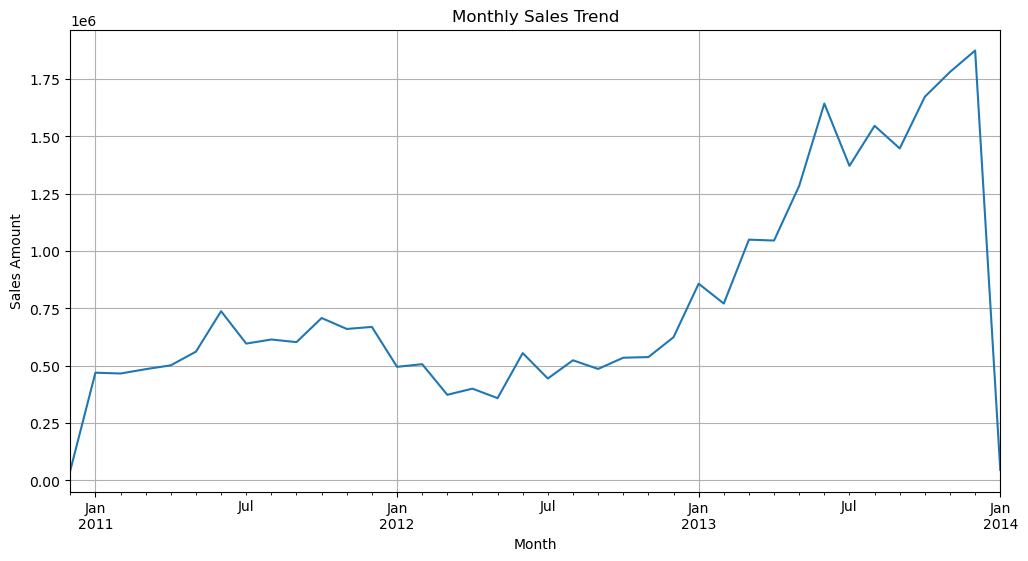

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

monthly.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")

plt.grid(True)

plt.show()

In [27]:
monthly.describe()

count    3.800000e+01
mean     7.723837e+05
std      4.718562e+05
min      4.341900e+04
25%      4.884525e+05
50%      5.998785e+05
75%      9.988345e+05
max      1.874128e+06
Name: SALES_AMOUNT, dtype: float64

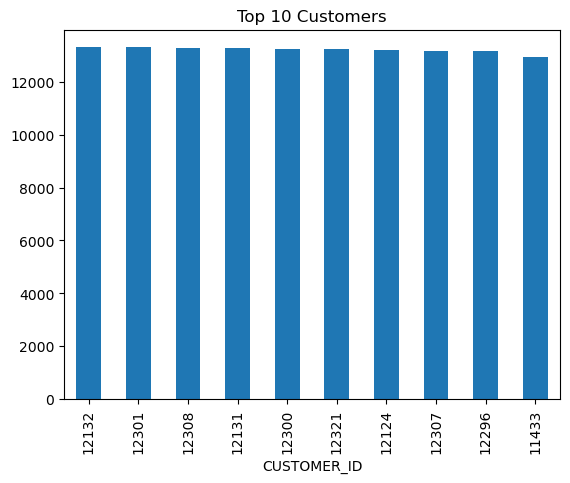

In [28]:
top_customers = (
    sales_df.groupby('CUSTOMER_ID')['SALES_AMOUNT']
            .sum()
            .sort_values(ascending=False)
            .head(10)
)

top_customers.plot(kind='bar')
plt.title('Top 10 Customers')
plt.show()

# 9. Product Performance Analysis

Products are ranked based on total sales.

This analysis identifies the strongest-performing products and helps optimize inventory planning.

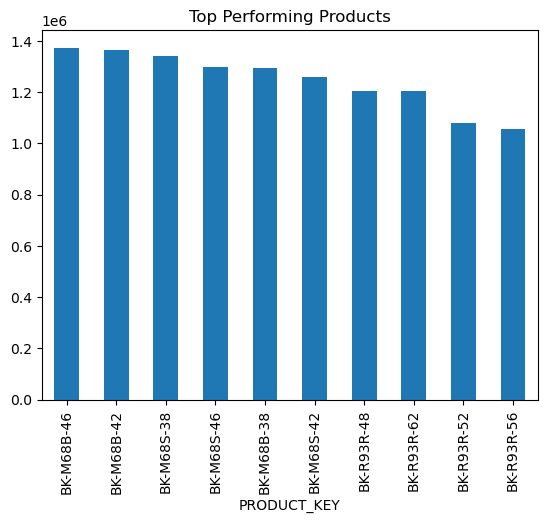

In [29]:
top_products = (
    sales_df.groupby('PRODUCT_KEY')['SALES_AMOUNT']
            .sum()
            .sort_values(ascending=False)
            .head(10)
)

top_products.plot(kind='bar')
plt.title('Top Performing Products')
plt.show()

# 10. Customer Segmentation

Customer purchasing behavior is explored by comparing

- purchase frequency
- total spending

This allows businesses to identify high-value customers and potential loyalty targets.

In [30]:
customer_value = (
    sales_df.groupby('CUSTOMER_ID')
            .agg({
                'SALES_AMOUNT':'sum',
                'ORDER_NUMBER':'count'
            })
)

customer_value.columns = [
    'Total_Sales',
    'Order_Count'
]

<Axes: xlabel='Order_Count', ylabel='Total_Sales'>

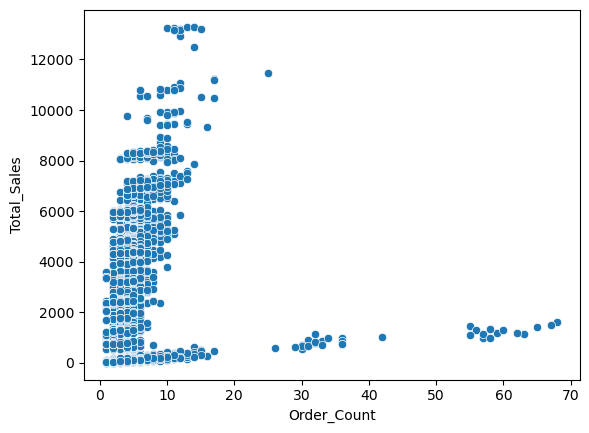

In [31]:
import seaborn as sns

sns.scatterplot(
    data=customer_value,
    x='Order_Count',
    y='Total_Sales'
)

# 11. Sales Forecasting

A simple Linear Regression model is trained using historical monthly sales data.

The objective is to estimate future sales trends and demonstrate predictive analytics.

In [32]:
forecast_df = monthly.reset_index()

forecast_df.columns = [
    'Month',
    'Sales'
]

In [33]:
from sklearn.linear_model import LinearRegression
import numpy as np

forecast_df['Time'] = range(len(forecast_df))

X = forecast_df[['Time']]
y = forecast_df['Sales']

model = LinearRegression()
model.fit(X, y)

forecast_df['Prediction'] = model.predict(X)

# 12. Forecast Visualization

The predicted sales values are compared with historical observations.

This visualization demonstrates how machine learning can support business planning and revenue forecasting.

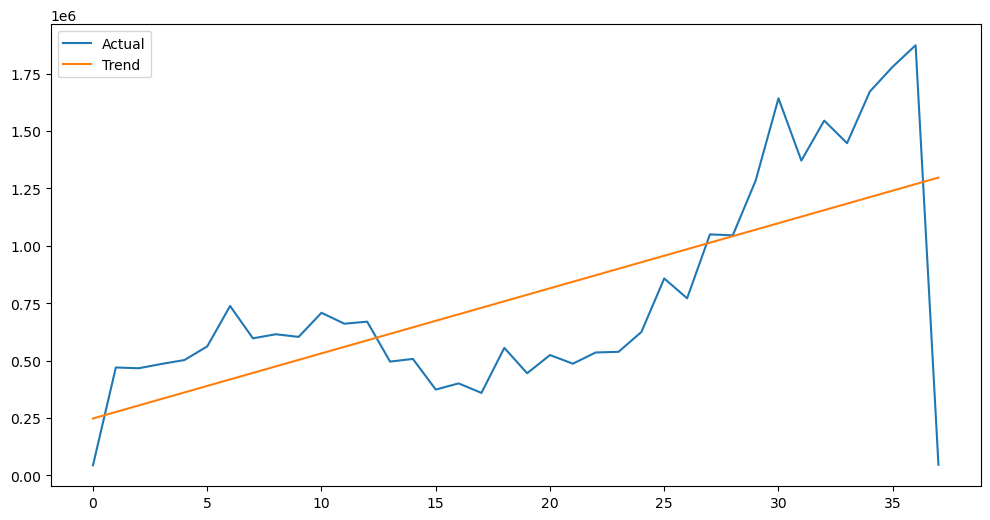

In [34]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df['Time'],
    forecast_df['Sales'],
    label='Actual'
)

plt.plot(
    forecast_df['Time'],
    forecast_df['Prediction'],
    label='Trend'
)

plt.legend()
plt.show()

In [35]:
forecast_df = monthly.reset_index()

forecast_df.columns = [
    'Month',
    'Sales'
]

In [36]:
forecast_df['Time'] = range(len(forecast_df))

In [37]:
from sklearn.linear_model import LinearRegression

X = forecast_df[['Time']]
y = forecast_df['Sales']

model = LinearRegression()

model.fit(X, y)

LinearRegression()

In [38]:
forecast_df['Prediction'] = model.predict(X)

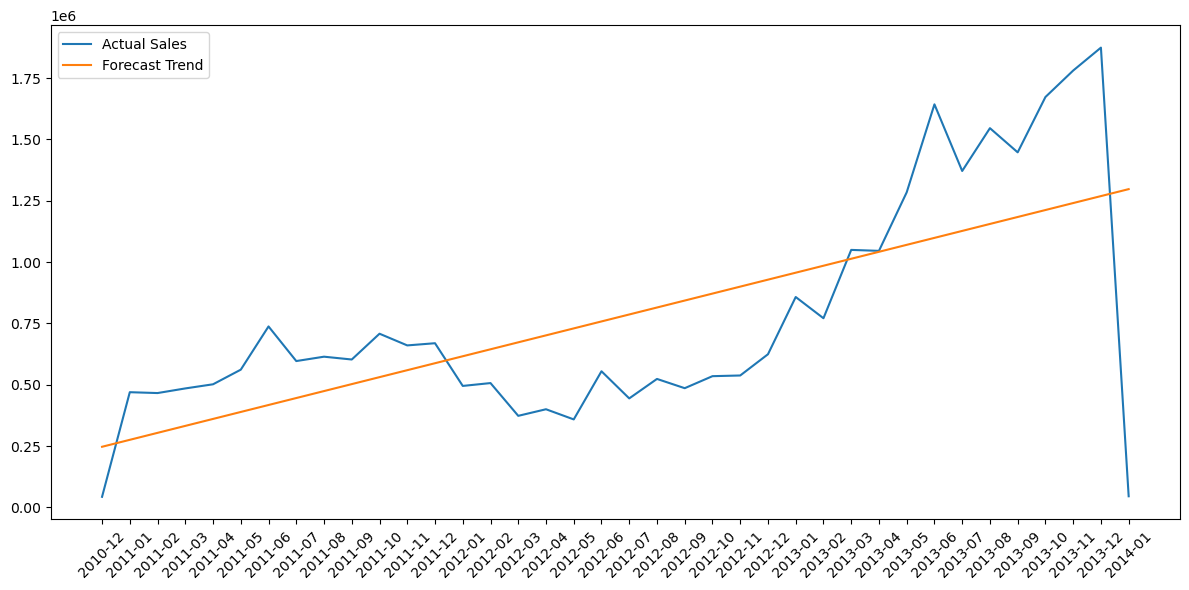

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    forecast_df['Month'].astype(str),
    forecast_df['Sales'],
    label='Actual Sales'
)

plt.plot(
    forecast_df['Month'].astype(str),
    forecast_df['Prediction'],
    label='Forecast Trend'
)

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Conclusion

This project demonstrated an end-to-end enterprise analytics workflow using Snowflake and Python.

## Key Achievements

- Connected Python to Snowflake
- Queried enterprise data using SQL
- Cleaned and transformed sales data
- Performed exploratory data analysis
- Identified customer and product trends
- Visualized business KPIs
- Developed a basic forecasting model

## Business Value

This workflow can support

- executive reporting
- customer analytics
- sales forecasting
- inventory planning
- strategic decision-making

## Future Improvements

- Deploy the forecasting model with FastAPI
- Automate data ingestion using Snowflake Tasks
- Build an interactive Power BI dashboard
- Compare multiple forecasting models (ARIMA, Prophet, XGBoost)
- Implement MLflow for model tracking

# Business Questions

This analysis aims to answer the following questions:

1. What is the company's total revenue?

2. Which customers generate the highest revenue?

3. Which products contribute the most to sales?

4. How do sales change over time?

5. Can future sales be predicted using historical trends?

6. What business actions can management take based on these insights?